<a href="https://colab.research.google.com/github/Bigenlight/Manipulator_study/blob/main/4_multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5-1강

# 다중분류 (MNIST)

처음으로 GPU 씀.

https://youtu.be/esphJUbvtrE?si=6UsIGyNHGrSg2X4w

In [1]:
import torch
# 데이터셋과 transforms으로 그 데이터들을 변형할 수 있는 함수들
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## 구글 드라이브와 연동 (코랩 새로 켤 때마다 지워지기 땜에)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 구글 GPU 좀 써보자

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


## train_DS 와 test_DS 구경

In [4]:
transform = transforms.ToTensor() # 아직 텐서 형태가 아니라 Tensor으로 바꿔줘야함.
# 이를 데이터셋 설정으로 넘김
train_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True, transform=transform)
test_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform)

In [24]:
print(train_DS)
print(test_DS)
print("train data 개수:", len(train_DS))
print("test data 개수:",len(test_DS))

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Test
    StandardTransform
Transform: ToTensor()
train data 개수: 60000
test data 개수: 10000


- train 6만
- test 1만

- 아래는 클래스 (라벨) 정보 출력

In [25]:
train_DS.classes # . 뒤에서 탭 하면 이것저것 볼 수 있는 게 뜬다

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [26]:
train_DS.class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [8]:
train_DS.data.shape

torch.Size([60000, 28, 28])

In [9]:
train_DS.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

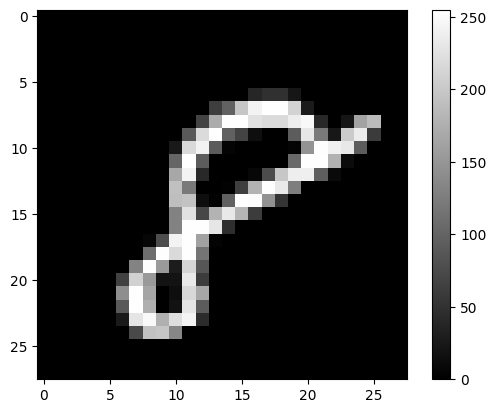

In [33]:
plt.imshow(train_DS.data[-1], cmap="gray")
plt.colorbar()

In [34]:
print(train_DS.targets)
print(train_DS.targets.shape)

tensor([5, 0, 4,  ..., 5, 6, 8])
torch.Size([60000])


## DataLoader 구경

In [36]:
# 미니배치 사이즈
BATCH_SIZE = 32

# 배치를 쓸 때 데이터로더를 필수적으로 사용함.
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

- 데이터 로더가 알아서 랜덤으로 배치 사이즈 만큼 가져옴

In [37]:
train_DL.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Train
    StandardTransform
Transform: ToTensor()

- 한번 한 배치 꺼내와보기

  - + ToTensor(transform)의 역할보기

<class 'torch.Tensor'>
torch.Size([60000, 28, 28])
torch.uint8
<class 'torch.Tensor'>
torch.Size([32, 1, 28, 28])
torch.float32
tensor(8)


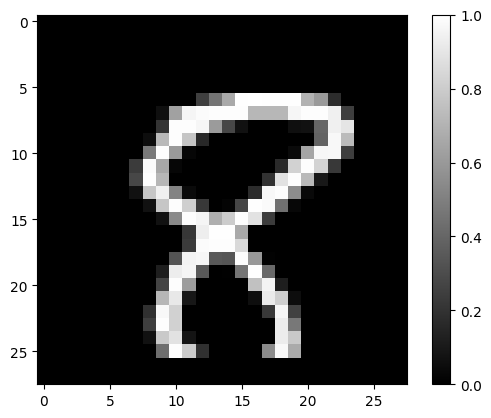

In [54]:
x_batch, y_batch = next(iter(train_DL)) # 데이터 한 국자 # next(iter(train_DS)) 는 한장만 꺼내기
# 위에서 데이터를 한국자 빼내면 알아서 ToTensor가 돌아감.

# ToTensor 전
print(type(train_DS.data))
print(train_DS.data.shape)
print(train_DS.data.dtype)
# print(train_DS.data[0])

# ToTensor 의 역할 # 데이터를 가져올때 transform 함수의 ToTensor를 거쳐감 +
# 1. tensor 로 바꾸고
# 2. 개채행열로 바꾸고
# 3. 0~1 사이로 바꾸고 (int -> float)

# ToTensor 후
print(type(x_batch))
print(x_batch.shape) # [32, 1, 28, 28]에서 1은 흑백이라서 1인겨.
print(x_batch.dtype)
# print(x_batch[0]) # binary로 잘 바뀌었음.

plt.imshow(x_batch[0].permute(1,2,0),cmap='gray')
plt.colorbar()
print(y_batch[0])

## 본격적으로 model 만들기!

In [56]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fcs = nn.Sequential(nn.Linear(28*28, 100), # 입력과 첫 은닉층
                                 nn.ReLU(),
                                 nn.Linear(100, 10)) # 출력
    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # flatten이 뭘까? 아래 보셈
        x = self.fcs(x)
        return x

In [58]:
# flatten 확인
x_batch, _ = next(iter(train_DL))
print(x_batch.shape)

# 원래 [32, 1, 28, 28]을 [25088]으로 평탄화시킴
flat_images = torch.flatten(x_batch)
print(flat_images.shape)

# 이거는 첫 32를 빼고 그 뒤 부터 평탄화 <- 이걸 위에서 사용함.
flat_images2 = torch.flatten(x_batch, start_dim=1)
print(flat_images2.shape)

torch.Size([32, 1, 28, 28])
torch.Size([25088])
torch.Size([32, 784])


- 왜 이렇게 flatten을 하고 모델을 돌릴까?

  - 우리가 nn.Linear에서 28*28으로 넣었다. 이는 28x28을 입력으로 받는게 아니라 당연히 784를 입력으로 받는거다.

- (중요) 모델과 데이터 모두 GPU에 올려야함.

In [59]:
# MLP 모델 GPU 올리기
model=MLP().to(DEVICE)
print(model)

x_batch, _ = next(iter(train_DL)) # 데이터 하나 가져오기
print(x_batch.shape)

model.eval()
with torch.no_grad():
    # x_batch의 데이터들도 GPU에 올려줘야함. (테스트로 한번 집어넣어보는 것)
    print(model(x_batch.to(DEVICE)).shape)

MLP(
  (fcs): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)
torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


- 다 올릴 필요는 없고 배치 데이터만 하나씩 올리면 됨

## 모델 훈련시키기!

In [62]:
from torch import optim

LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss() # CEE 손실함수 # 안에 Softmax를 포함하고 있음!! +++
optimizer = optim.Adam(model.parameters(), lr=LR) # 아담 옵티마이저

def Train(model, train_DL, criterion, optimizer, EPOCH):

    loss_history=[]
    NoT=len(train_DL.dataset) # The number of training data
    print(NoT)
    model.train() # train mode로 전환
    for ep in range(EPOCH):
        rloss = 0 # running loss
        for x_batch, y_batch in train_DL: # 데이터를 데이터로더 부터 꺼내기
            # 배치 데이터 GPU에 올리기 +
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # (모델은 아까 올려서 지금은 안올려도 됨)

            # inference
            y_hat = model(x_batch)

            # loss
            loss = criterion(y_hat, y_batch)

            # update
            optimizer.zero_grad() # gradient 누적을 막기 위한 초기화
            loss.backward() # backpropagation
            optimizer.step() # weight update
            # loss accumulation
            loss_b = loss.item() * x_batch.shape[0] # batch loss # BATCH_SIZE를 곱하면 마지막 18개도 32개를 곱하니까..
            rloss += loss_b # running loss

        # print loss
        loss_e = rloss/NoT # epoch loss
        loss_history += [loss_e]
        print(f"Epoch: {ep+1}, train loss: {loss_e:.3f}")
        print("-"*20)

    return loss_history

- 아래쪽에 `loss_e = rloss/NoT `을 한 이유는 **제대로된 Loss 평균**을 구하고 싶어서임.
  - 예를 들어 총 데이터가 50개인데 배치가 32이면, 한쪽 배치는 32의 Loss 평균을 구하게되고, 나머지 한쪽은 18끼리의 평균임. 이게 서로 좀 다를 수도 있음.
  - 그래서 그냥 전체 Loss를 위 rloss에서 축적하고, 아래에서 Epoch (6만개의 데이터를 다 돌렸을 때) 총 데이터의 수 만큼 나누는 것이다.
  - 이를 실제로 쓰는 것은 아니고, 지표에 쓰이는 듯?

- 실제 학습

60000
Epoch: 1, train loss: 0.313
--------------------
Epoch: 2, train loss: 0.145
--------------------
Epoch: 3, train loss: 0.098
--------------------
Epoch: 4, train loss: 0.075
--------------------
Epoch: 5, train loss: 0.059
--------------------


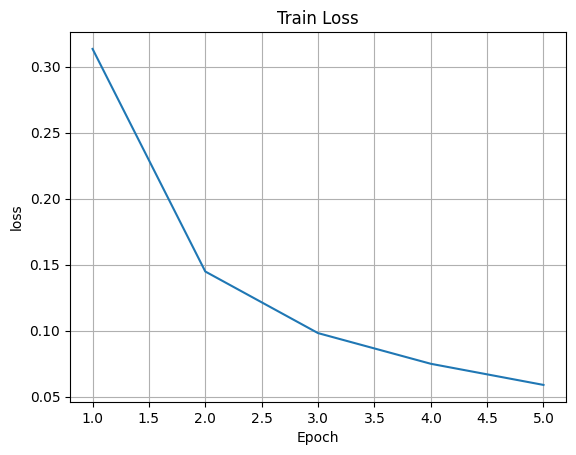

In [64]:
loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

plt.plot(range(1,EPOCH+1),loss_history)
plt.xlabel("Epoch")
plt.ylabel("loss")ㅡㅡㅡ
plt.title("Train Loss")
plt.grid()

## Cross Entropy 확인 (왜 모델에 softmax를 안붙였을까?)

- Softmax가 안에 잘 들어있는지 체크하기


In [63]:
# cross entropy 구하는 여러가지 방법
import torch.nn.functional as F

y_hat = torch.randn(3, 5) # data는 세 개, 5 종류로 분류하는 문제 가정
print(y_hat) # 가로 축으로 합이 1이 아님, 즉, softmax 통과 전
y_batch = torch.randint(5, (3,))
print(y_batch)

# 방법 1 - nn.functional의 CEE
loss = F.cross_entropy(y_hat, y_batch) # softmax가 내장
print(loss)

# 방법 2 - nn으로 CEE
criterion = nn.CrossEntropyLoss() # softmax가 내장
print(criterion(y_hat,y_batch))

# 방법 3 - 직접 Softmax 넣어 CEE하기
soft = nn.Softmax(dim=1)
y_hat_soft = soft(y_hat)
print(y_hat_soft)
loss = 0
for i, val in enumerate(y_hat_soft):
    print(i,val)
    loss += -torch.log(val[y_batch[i]])
print(loss/3) # 평균이 내장되어있음을 알 수 있다

tensor([[ 1.4633, -0.0060, -0.3897,  0.1934, -2.3327],
        [ 0.5916,  0.3827, -0.0806, -0.6200,  0.2859],
        [-0.3079,  1.1650,  0.8503, -0.0234, -0.9957]])
tensor([2, 1, 3])
tensor(1.9509)
tensor(1.9509)
tensor([[0.5916, 0.1361, 0.0928, 0.1662, 0.0133],
        [0.2979, 0.2418, 0.1521, 0.0887, 0.2195],
        [0.0964, 0.4203, 0.3068, 0.1281, 0.0484]])
0 tensor([0.5916, 0.1361, 0.0928, 0.1662, 0.0133])
1 tensor([0.2979, 0.2418, 0.1521, 0.0887, 0.2195])
2 tensor([0.0964, 0.4203, 0.3068, 0.1281, 0.0484])
tensor(1.9509)


- 결과가 다 똑같음. -> CEE안에 다 Softmax가 있다!

## 모델 저장하기 & 불러오기

- 아래 구글드라이브 경로에 results 폴더를 수동으로 만들어야함.

In [66]:
# import os # 이건 내 필기용
# os.mkdir("/content/drive/MyDrive/Colab Notebooks/results") # 이건 내 필기용

save_model_path = "/content/drive/MyDrive/Colab Notebooks/results/MLP.pt"
torch.save(model.state_dict(), save_model_path)

- `model.state_dict()`는 모델의 파라미터를 **딕셔너리**로 지정함. 확장자는 `.pt`



In [69]:
# model.state_dict() # 딕셔너리로 저장된 모델 구경하기

- 그러면 이제 불러오는 것은?

In [70]:
# 일단 우리가 만들어든 MLP 클래스로 껍데기를 만들고
load_model = MLP().to(DEVICE)

# 그 껍데기에 딕셔너리에 저장된 파라미터들을 올려줌.
load_model.load_state_dict(torch.load(save_model_path, map_location=DEVICE))
# map_location 있어야 GPU로 학습했던 거 현재 device로 불러올 수 있음

<All keys matched successfully>

## 모델 테스트하기

- 이 코드는 학습이 아니라 그냥 inference가 끝이라 조금 더 간단함.

In [86]:
def Test(model, test_DL):
    model.eval() # test mode로 전환
    with torch.no_grad(): # grad 계산 ㄴㄴ
        rcorrect = 0
        for x_batch, y_batch in test_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            # inference
            y_hat = model(x_batch)

            # corrects accumulation
            pred = y_hat.argmax(dim=1) # 10 결과값 중에서 최고 뽑기
            # 진짜 잘 맞췄는지 대조하고 그 개수를 세기
            corrects_b = torch.sum(pred == y_batch).item() # torch.eq(pred, y_batch).sum().item()
            rcorrect += corrects_b # 이건 한 배치에 대해서 구한거니 계속 누적해야함.

        # 전체 test 데이터에 대한 정확도.
        accuracy_e = rcorrect/len(test_DL.dataset)*100
    print(f"Test accuracy: {rcorrect}/{len(test_DL.dataset)} ({accuracy_e:.1f} %)")
    return round(accuracy_e,1)

In [88]:
Test(load_model, test_DL) # 우리가 가져온 load_model으로 테스트

Test accuracy: 9741/10000 (97.4 %)


97.4

### 모델 테스트 시각화하기

- 맞췄으면 초록, 틀렸으면 파랑



In [91]:
def Test_plot(model, test_DL):
    model.eval()
    with torch.no_grad():
        x_batch, y_batch = next(iter(test_DL))
        x_batch = x_batch.to(DEVICE)
        y_hat = model(x_batch)
        pred = y_hat.argmax(dim=1)

    x_batch = x_batch.to("cpu")
    # print(x_batch.shape)

    plt.figure(figsize=(8,4))
    for idx in range(6):
        plt.subplot(2,3, idx+1, xticks=[], yticks=[])
        plt.imshow(x_batch[idx].permute(1,2,0), cmap="gray")
        pred_class = test_DL.dataset.classes[pred[idx]]
        true_class = test_DL.dataset.classes[y_batch[idx]]
        plt.title(f"{pred_class} ({true_class})", color = "g" if pred_class==true_class else "r")

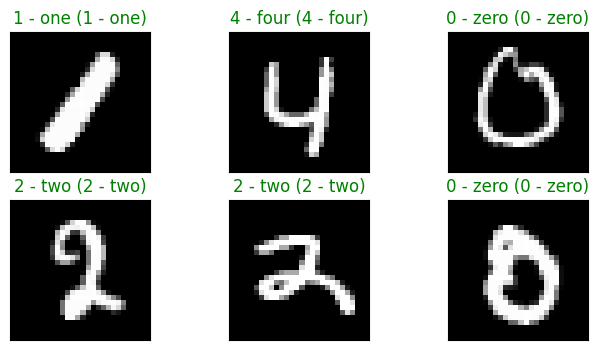

In [108]:
Test_plot(load_model, test_DL)

In [75]:
# 파라미터 수 구하기
def count_params(model):
    num = sum([p.numel() for p in model.parameters() if p.requires_grad])
    return num

- 이 모델은 약 8만개의 파라미터를 가지고 있음.

In [76]:
print(count_params(load_model))

79510


## confusion matrix

- 딥러닝때 쓰기 좋은 그래프

In [109]:
def get_conf(model, test_DL):
    N = len(test_DL.dataset.classes)
    model.eval()
    with torch.no_grad():
        confusion = torch.zeros(N,N)
        for x_batch, y_batch in test_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # inference
            y_hat = model(x_batch)
            # accuracy
            pred = y_hat.argmax(dim=1)

            confusion += torch.bincount(N * y_batch.cpu() + pred.cpu(), minlength=N**2).reshape(N, N)
            # confusion matrix는 무조건 10x10이 되어야 하는데 만약 마지막 label에 대해 예측을 모두 실패하면 100개보다 작아질 수 있기 때문에 minlength를 설정

    confusion = confusion.numpy()

    return confusion

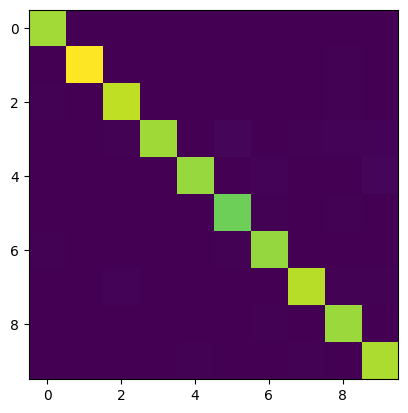

In [110]:
confusion = get_conf(load_model, test_DL)
plt.imshow(confusion)

In [111]:
import numpy as np

def plot_confusion_matrix(confusion, classes=None):
    N = confusion.shape[0]
    accuracy=np.trace(confusion)/np.sum(confusion) * 100

    # confusion = confusion/np.sum(confusion, axis=1)
    plt.figure(figsize=(10,7))
    plt.imshow(confusion, cmap="Blues")
    plt.title("confusion matrix")
    plt.colorbar()

    for i in range(N):
        for j in range(N):
            plt.text(j,i, round(confusion[i,j]),
                     horizontalalignment="center", fontsize=10,
                     color="white" if confusion[i,j] > np.max(confusion) / 1.5 else "black")

    if classes is not None:
        plt.xticks(range(N), classes)
        plt.yticks(range(N), classes)
    else:
        plt.xticks(range(N))
        plt.yticks(range(N))

    plt.xlabel(f"Predicted label \n accuracy = {accuracy:.1f} %")
    plt.ylabel("True label")

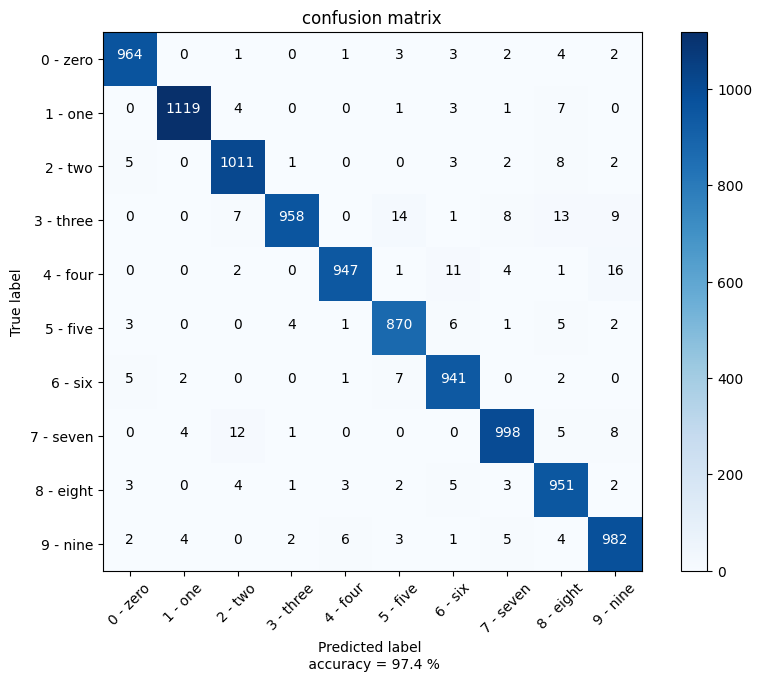

In [112]:
confusion = get_conf(load_model, test_DL)
plot_confusion_matrix(confusion, test_DS.classes)
plt.xticks(rotation=45);

- 위 그래프는 뭘 어떻게 틀렸냐를 보기 좋음. 대각선은 정답을 정답으로 잘 맞춘 것. 그리고 나머지는 틀린 것.

- 예를 들어 실제 4를 9로 잘못 보는 경우가 16번으로 가장 많음. 이를 보고 해결책을 고민하기 좋음. (예를 들어 4와 9에 대한 데이터를 특별히 높인다는가 등.)